# Predicting Customer Lifetime Value for New E-Commerce Users with A Machine Learning Regression Approach

 Below are the codes which i have implemented for my research work.

- Vaddi Pradeep Satya Chandra
- Master of Science in Data Science
- Liverpool John Moores University
- LJMU Student ID: 1187394


### Importing Required libraries

Import necessary libraries for data manipulation, visualization, machine learning, and statistical analysis.

In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Feature Selection
from sklearn.feature_selection import mutual_info_regression, RFE

# For explainable AI (SHAP values)
import shap
# For statistical testing (e.g., t-tests)
from scipy import stats

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

### 1. Data Loading

Load the dataset from the specified CSV file into a pandas DataFrame and display the first few rows.

In [ ]:
df = pd.read_csv("online_sales_dataset.csv")

display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Discount,PaymentMethod,ShippingCost,Category,SalesChannel,ReturnStatus,ShipmentProvider,WarehouseLocation,OrderPriority
0,221958,SKU_1964,White Mug,38,1/1/2020 0:00,1.71,37039.0,Australia,0.470000,Bank Transfer,10.79,Apparel,In-store,Not Returned,UPS,London,Medium
1,771155,SKU_1241,White Mug,18,1/1/2020 1:00,41.25,19144.0,Spain,0.190000,paypall,9.51,Electronics,Online,Not Returned,UPS,Rome,Medium
2,231932,SKU_1501,Headphones,49,1/1/2020 2:00,29.11,50472.0,Germany,0.350000,Bank Transfer,23.03,Electronics,Online,Returned,UPS,Berlin,High
3,465838,SKU_1760,Desk Lamp,14,1/1/2020 3:00,76.68,96586.0,Netherlands,0.140000,paypall,11.08,Accessories,Online,Not Returned,Royal Mail,Rome,Low
4,359178,SKU_1386,USB Cable,-30,1/1/2020 4:00,-68.11,NaN,United Kingdom,1.501433,Bank Transfer,NaN,Electronics,In-store,Not Returned,FedEx,NaN,Medium


### 2. Initial Data Inspection

Display a summary of the DataFrame including data types, non-null values, descriptive statistics, and missing value counts per column.

In [ ]:
df.info()
display(df.describe())
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49782 entries, 0 to 49781
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   InvoiceNo          49782 non-null  int64  
 1   StockCode          49782 non-null  object 
 2   Description        49782 non-null  object 
 3   Quantity           49782 non-null  int64  
 4   InvoiceDate        49782 non-null  object 
 5   UnitPrice          49782 non-null  float64
 6   CustomerID         44804 non-null  float64
 7   Country            49782 non-null  object 
 8   Discount           49782 non-null  float64
 9   PaymentMethod      49782 non-null  object 
 10  ShippingCost       47293 non-null  float64
 11  Category           49782 non-null  object 
 12  SalesChannel       49782 non-null  object 
 13  ReturnStatus       49782 non-null  object 
 14  ShipmentProvider   49782 non-null  object 
 15  WarehouseLocation  46297 non-null  object 
 16  OrderPriority      497

,InvoiceNo,Quantity,UnitPrice,CustomerID,Discount,ShippingCost
count,49782.000000,49782.000000,49782.000000,44804.000000,49782.000000,47293.000000
mean,550681.239946,22.372343,47.537862,55032.871775,0.275748,17.494529
std,260703.009944,17.917774,33.479510,25913.660157,0.230077,7.220557
min,100005.000000,-50.000000,-99.980000,10001.000000,0.000000,5.000000
25%,324543.000000,11.000000,23.592500,32750.750000,0.130000,11.220000
50%,552244.000000,23.000000,48.920000,55165.000000,0.260000,17.500000
75%,776364.000000,37.000000,74.610000,77306.250000,0.380000,23.720000
max,999997.000000,49.000000,100.000000,99998.000000,1.999764,30.000000


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,4978
Country,0
Discount,0
PaymentMethod,0


Visualize missing values across all columns using a bar plot. Also, plot distributions and box plots for numerical columns to identify skewness and outliers.

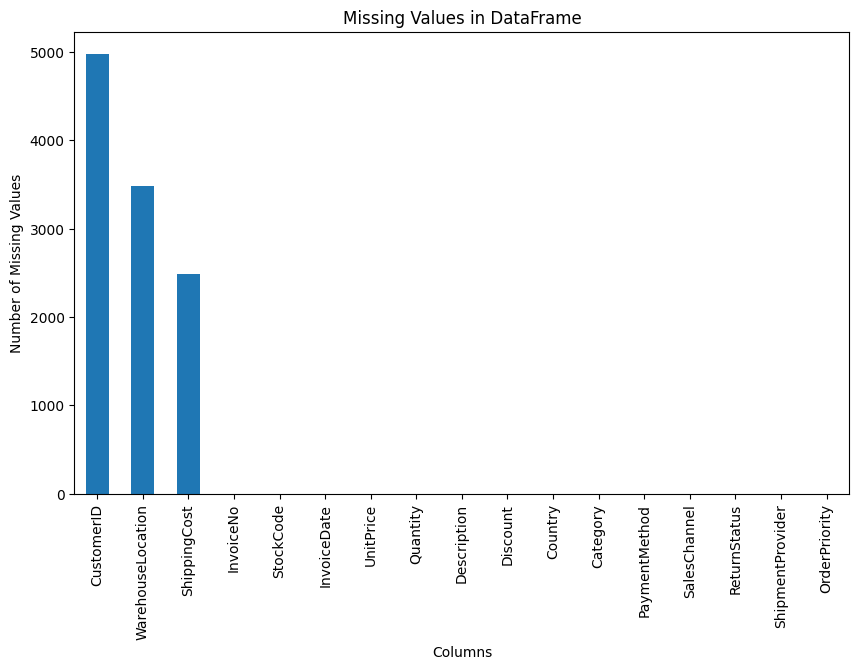

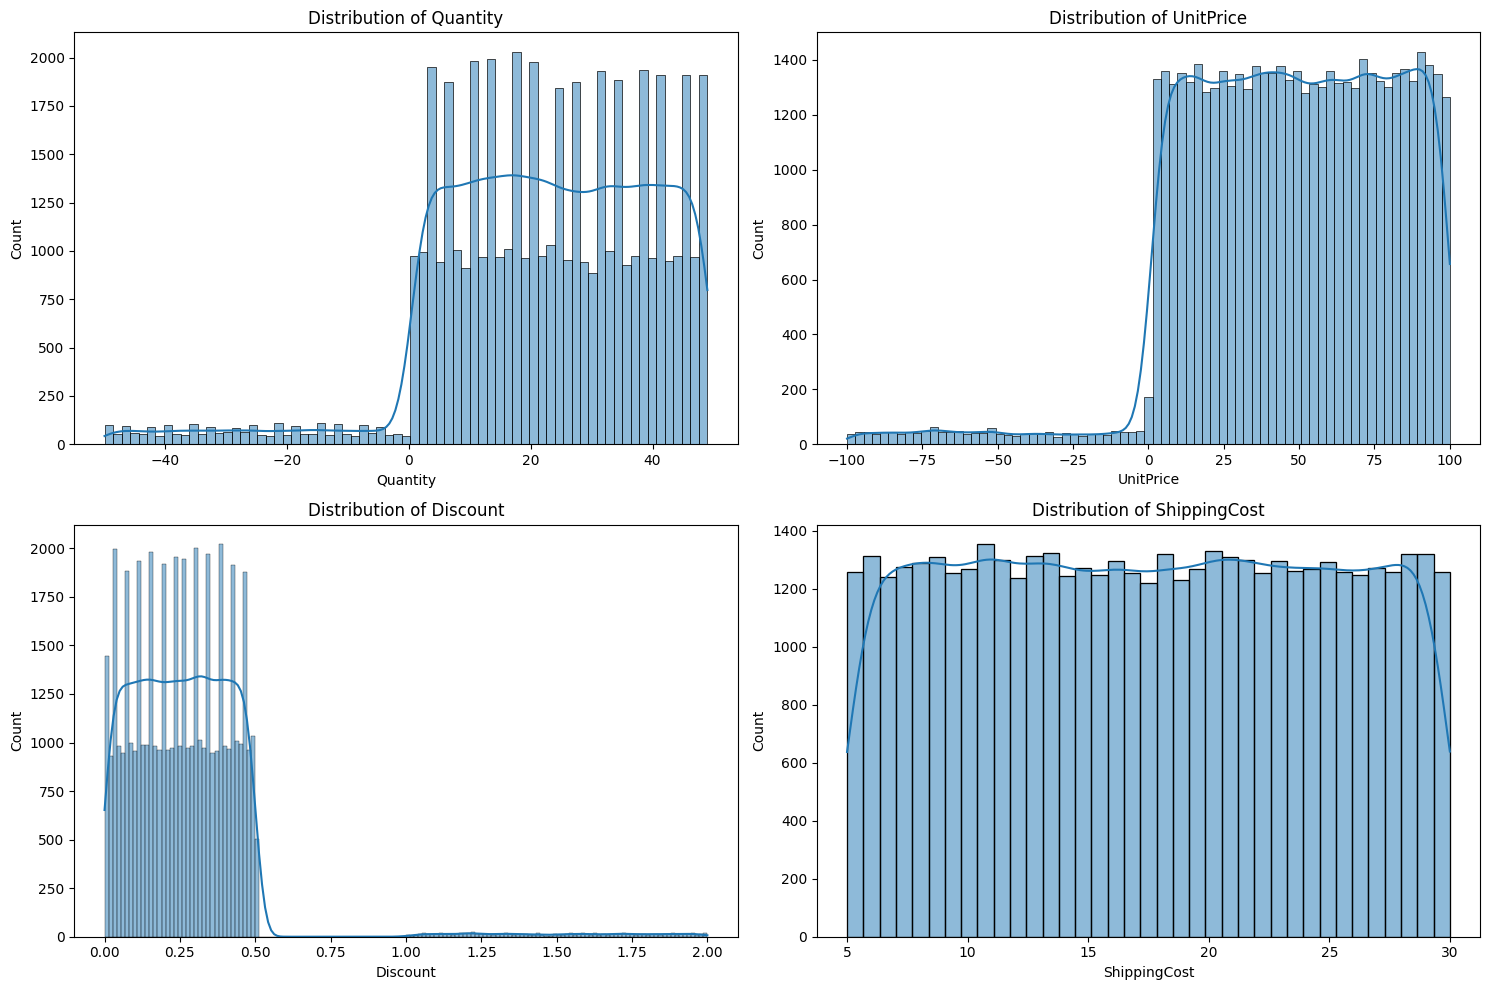

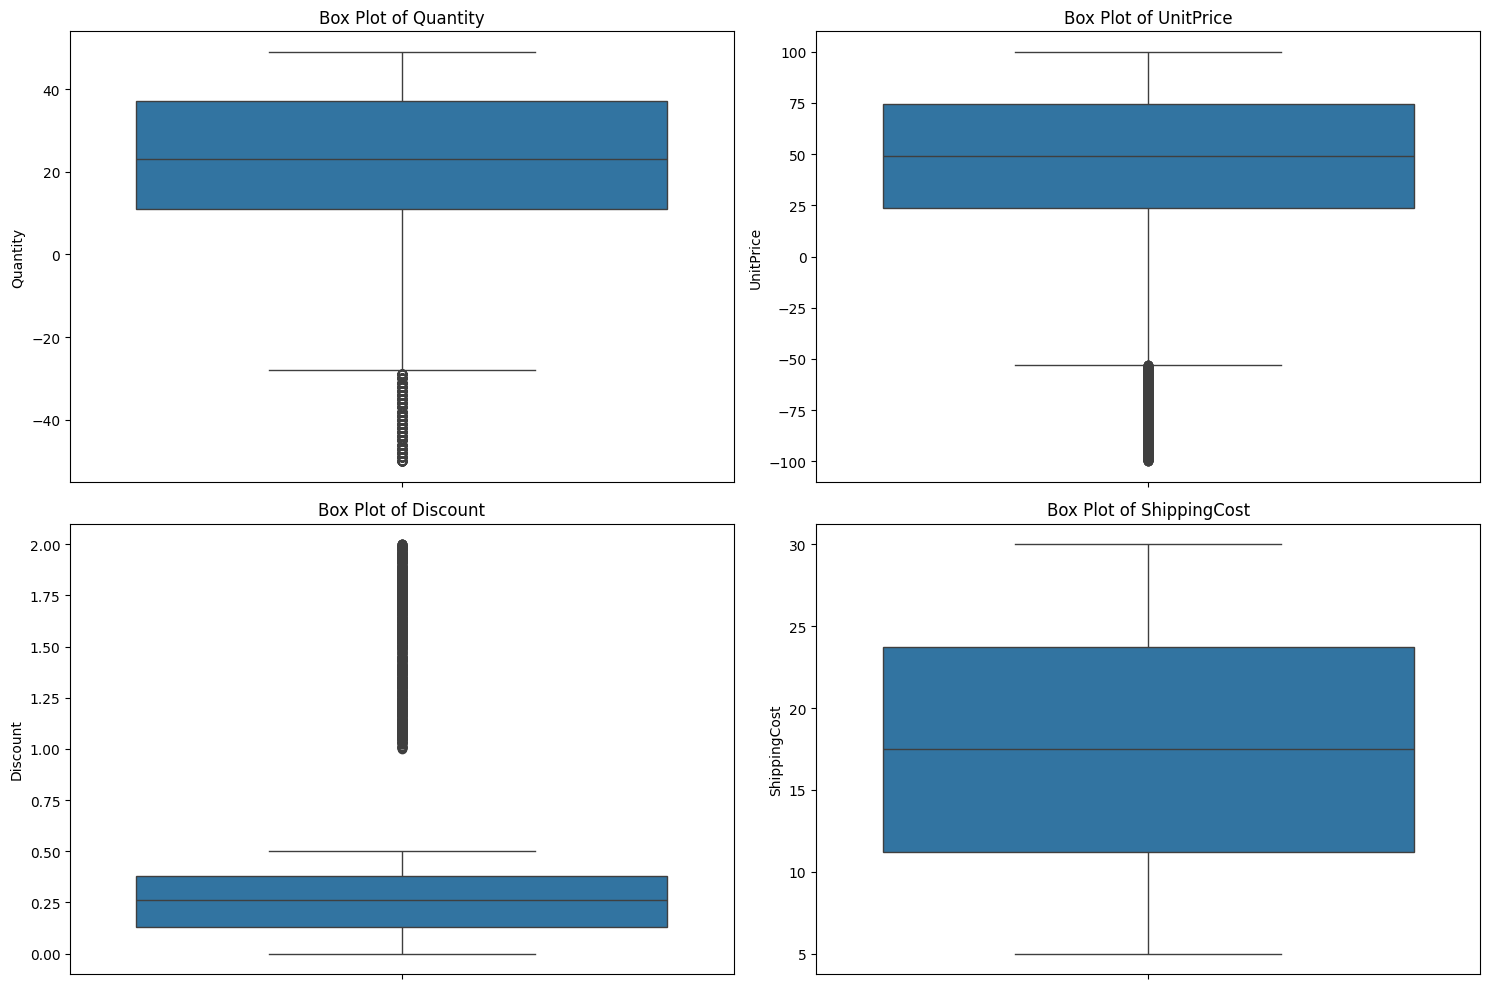

In [ ]:
# Visualize missing values
plt.figure(figsize=(10, 6))
df.isnull().sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Missing Values in DataFrame')
plt.ylabel('Number of Missing Values')
plt.xlabel('Columns')
plt.show()

# Select numerical columns from the original df for distribution and outlier analysis
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Exclude 'InvoiceNo' and 'CustomerID' if they are just identifiers and not actual numerical measures
numerical_cols = [col for col in numerical_cols if col not in ['InvoiceNo', 'CustomerID']]

if not numerical_cols:
    print("No suitable numerical columns found in df for distribution and outlier analysis.")
else:
    # Visualize distributions (skewness)
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(numerical_cols):
        plt.subplot(2, int(np.ceil(len(numerical_cols)/2)), i + 1)
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # Visualize outliers
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(numerical_cols):
        plt.subplot(2, int(np.ceil(len(numerical_cols)/2)), i + 1)
        sns.boxplot(y=df[col])
        plt.title(f'Box Plot of {col}')
        plt.ylabel(col) # Explicitly setting y-label for box plots
    plt.tight_layout()
    plt.show()

### 3. Data Cleaning and Preprocessing

Perform data cleaning steps: drop rows with missing CustomerID, impute missing ShippingCost with the mean, and remove any duplicate records.

In [ ]:
# Drop rows without CustomerID
df = df.dropna(subset=['CustomerID'])

# Fill ShippingCost with mean
df['ShippingCost'].fillna(df['ShippingCost'].mean(), inplace=True)

# Remove duplicate records
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Removed {initial_rows - df.shape[0]} duplicate rows.")

Removed 0 duplicate rows.


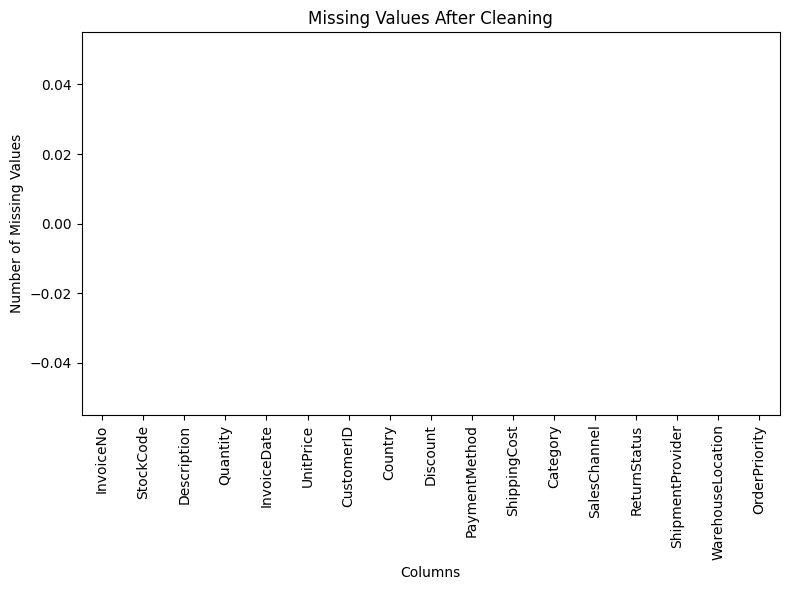

In [ ]:
# Visualize the remaining missing values after cleaning to confirm the imputation and drops.
plt.figure(figsize=(8, 6))
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values After Cleaning")
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.tight_layout()
plt.show()

In [ ]:
# Convert the 'InvoiceDate' column to datetime objects for time-based calculations.
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

### 4. Feature Engineering (Cold Start, RFM, Logistics, CLV Calculation)

Perform feature engineering: filter out negative quantities, calculate TotalPrice, determine first purchase dates, calculate days since first purchase, define cold start period data, and calculate Customer Lifetime Value (CLV).

In [ ]:
# Remove negative quantities (returns) before feature engineering that relies on positive transactions
df = df[df['Quantity'] > 0]

# Create total revenue column (used for both Monetary feature and CLV calculation)
df['TotalPrice'] = df['UnitPrice'] * df['Quantity']

# First purchase date for each customer
first_purchase = df.groupby('CustomerID')['InvoiceDate'].min().reset_index()
first_purchase.columns = ['CustomerID', 'FirstPurchaseDate']

# Merge first purchase date back to the main DataFrame
df = df.merge(first_purchase, on='CustomerID')

# Calculate Days since first purchase for each transaction
df['DaysFromFirstPurchase'] = (df['InvoiceDate'] - df['FirstPurchaseDate']).dt.days

# Define the cold start period data (first 0-90 days of customer activity)
# This will be used to generate RFM and Logistics features
df_cold = df[(df['DaysFromFirstPurchase'] >= 0) & (df['DaysFromFirstPurchase'] <= 90)]

# Define the future period for CLV calculation (transactions occurring after the 90-day cold start period)
future = df[df['DaysFromFirstPurchase'] > 90]

# Calculate CLV: sum of TotalPrice for transactions in the future period for each customer
clv = future.groupby('CustomerID')['TotalPrice'].sum().reset_index()
clv.columns = ['CustomerID', 'CLV']


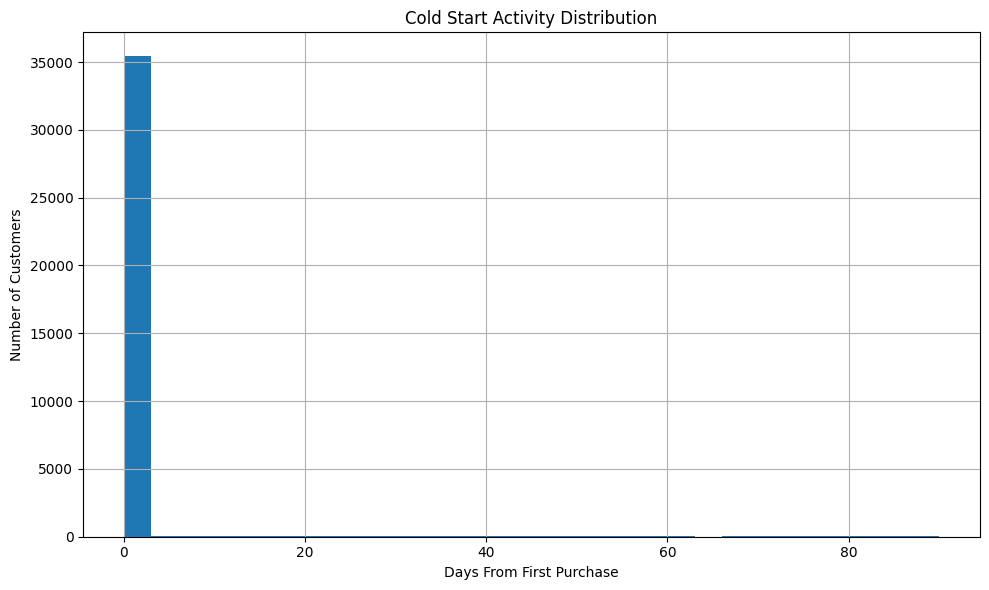

In [ ]:
# Visualize the distribution of 'DaysFromFirstPurchase' within the cold start period to understand customer activity patterns.
plt.figure(figsize=(10, 6))
df_cold['DaysFromFirstPurchase'].hist(bins=30)
plt.title("Cold Start Activity Distribution")
plt.xlabel("Days From First Purchase")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [ ]:
# Calculate RFM (Recency, Frequency, Monetary) features for each customer based on their cold start period transactions.
rfm = df_cold.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (df_cold['InvoiceDate'].max() - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
display(rfm.head())

,CustomerID,Recency,Frequency,Monetary
0,10001.0,740,1,1516.22
1,10003.0,1841,1,377.05
2,10005.0,555,1,790.40
3,10008.0,144,1,62.60
4,10009.0,1824,1,827.84


In [ ]:
# Engineer 'logistics' features including ReturnRate and the most frequent OrderPriorityMode for each customer during the cold start period.
logistics = df_cold.groupby('CustomerID').agg({
    'ReturnStatus': lambda x: (x == 'Returned').mean(),
    'OrderPriority': lambda x: x.mode()[0]
}).reset_index()

logistics.columns = ['CustomerID', 'ReturnRate', 'OrderPriorityMode']
display(logistics.head())

,CustomerID,ReturnRate,OrderPriorityMode
0,10001.0,0.0,High
1,10003.0,0.0,Medium
2,10005.0,0.0,Low
3,10008.0,0.0,High
4,10009.0,0.0,Medium


In [ ]:
# Merge the RFM features, logistics features, and calculated CLV to create a comprehensive dataset for modeling.
features = rfm.merge(logistics, on='CustomerID')
data = features.merge(clv, on='CustomerID', how='inner')
display(data.head())

,CustomerID,Recency,Frequency,Monetary,ReturnRate,OrderPriorityMode,CLV
0,10005.0,555,1,790.40,0.0,Low,1736.75
1,10010.0,2033,1,273.00,1.0,Medium,3113.28
2,10020.0,1452,1,1475.16,0.0,High,653.67
3,10023.0,1138,1,2137.32,0.0,High,822.38
4,10045.0,967,1,2555.48,0.0,Low,784.98


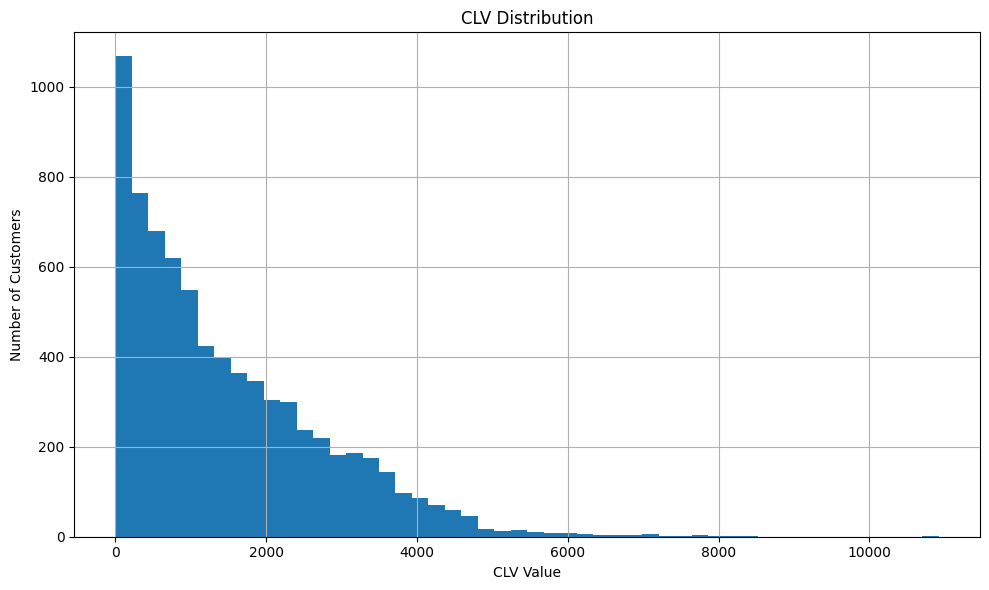

In [ ]:
# Visualize the distribution of the calculated Customer Lifetime Value (CLV) to understand its spread and potential skewness.
plt.figure(figsize=(10, 6))
data['CLV'].hist(bins=50)
plt.title("CLV Distribution")
plt.xlabel("CLV Value")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### 5. One-Hot Encoding and Feature Scaling

In [ ]:
# Apply one-hot encoding to the 'OrderPriorityMode' categorical feature, dropping the first category to avoid multicollinearity.
data = pd.get_dummies(data, columns=['OrderPriorityMode'], drop_first=True)
display(data.head())

,CustomerID,Recency,Frequency,Monetary,ReturnRate,CLV,OrderPriorityMode_Low,OrderPriorityMode_Medium
0,10005.0,555,1,790.40,0.0,1736.75,True,False
1,10010.0,2033,1,273.00,1.0,3113.28,False,True
2,10020.0,1452,1,1475.16,0.0,653.67,False,False
3,10023.0,1138,1,2137.32,0.0,822.38,False,False
4,10045.0,967,1,2555.48,0.0,784.98,True,False


In [ ]:
# Initialize a MinMaxScaler and apply it to scale the numerical features ('Recency', 'Frequency', 'Monetary', 'ReturnRate') to a 0-1 range.
scaler = MinMaxScaler()
scaled_cols = ['Recency', 'Frequency', 'Monetary', 'ReturnRate']

data[scaled_cols] = scaler.fit_transform(data[scaled_cols])
display(data.head())

logistics_categorical = ['OrderPriorityMode']

print(f"Encoding check: Features currently in X_B: {data.drop(['CustomerID', 'CLV'], axis=1).columns.tolist()}")


,CustomerID,Recency,Frequency,Monetary,ReturnRate,CLV,OrderPriorityMode_Low,OrderPriorityMode_Medium
0,10005.0,0.223926,0.0,0.106057,0.0,1736.75,True,False
1,10010.0,0.979550,0.0,0.036537,1.0,3113.28,False,True
2,10020.0,0.682515,0.0,0.198063,0.0,653.67,False,False
3,10023.0,0.521984,0.0,0.287032,0.0,822.38,False,False
4,10045.0,0.434560,0.0,0.343218,0.0,784.98,True,False


Encoding check: Features currently in X_B: ['Recency', 'Frequency', 'Monetary', 'ReturnRate', 'OrderPriorityMode_Low', 'OrderPriorityMode_Medium']


### 6. Data Splitting and Model Initialization

Define feature sets for two models: Model A (RFM features only) and Model B (RFM + Logistics features), and set 'CLV' as the target variable.

In [ ]:
# Model A (RFM only)
X_A = data[['Recency', 'Frequency', 'Monetary']]

# Model B (RFM + Logistics)
X_B = data.drop(['CustomerID', 'CLV'], axis=1)

y = data['CLV']

In [ ]:
# Split the data into training and testing sets for both Model A and Model B, using an 80/20 ratio and a fixed random state for reproducibility.
X_train_A, X_test_A, y_train, y_test = train_test_split(X_A, y, test_size=0.2, random_state=42)
X_train_B, X_test_B, _, _ = train_test_split(X_B, y, test_size=0.2, random_state=42)

In [ ]:
# Initialize three regression models: Linear Regression, Random Forest Regressor, and XGBoost Regressor, with specified random states for reproducibility.
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

### 7. Model Evaluation (Cross-Validation)

Perform 5-fold cross-validation for each initialized model on both Model A (RFM) and Model B (RFM + Logistics) feature sets.


In [ ]:
# Evaluate performance using RMSE, MAE, and R2 scores, then display the combined results.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results_A = []
rmse_scores_A_dict = {}

for name, model in models.items():
    rmse_scores = np.sqrt(-cross_val_score(model, X_A, y, cv=kf, scoring='neg_mean_squared_error'))
    mae_scores = -cross_val_score(model, X_A, y, cv=kf, scoring='neg_mean_absolute_error')
    r2_scores = cross_val_score(model, X_A, y, cv=kf, scoring='r2')

    rmse_mean = np.mean(rmse_scores)
    mae_mean = np.mean(mae_scores)
    r2_mean = np.mean(r2_scores)

    results_A.append([f"{name} (Model A)", rmse_mean, mae_mean, r2_mean])
    rmse_scores_A_dict[name] = rmse_scores

results_df_A = pd.DataFrame(results_A, columns=['Model', 'RMSE', 'MAE', 'R2'])

results_B = []
rmse_scores_B_dict = {}

for name, model in models.items():
    rmse_scores = np.sqrt(-cross_val_score(model, X_B, y, cv=kf, scoring='neg_mean_squared_error'))
    mae_scores = -cross_val_score(model, X_B, y, cv=kf, scoring='neg_mean_absolute_error')
    r2_scores = cross_val_score(model, X_B, y, cv=kf, scoring='r2')

    rmse_mean = np.mean(rmse_scores)
    mae_mean = np.mean(mae_scores)
    r2_mean = np.mean(r2_scores)

    results_B.append([f"{name} (Model B)", rmse_mean, mae_mean, r2_mean])
    rmse_scores_B_dict[name] = rmse_scores

results_df_B = pd.DataFrame(results_B, columns=['Model', 'RMSE', 'MAE', 'R2'])

# Combine results for comparison
combined_results_df = pd.concat([results_df_A, results_df_B])
display(combined_results_df.set_index('Model'))

,RMSE,MAE,R2
Model,,,
Linear Regression (Model A),1280.671629,1028.273259,0.001914
Random Forest (Model A),1381.298022,1092.285537,-0.161441
XGBoost (Model A),1374.347060,1085.557184,-0.149648
Linear Regression (Model B),1281.236106,1028.712563,0.001029
Random Forest (Model B),1368.210991,1086.595740,-0.139487
XGBoost (Model B),1380.576459,1092.315640,-0.160143


<Figure size 1200x600 with 0 Axes>

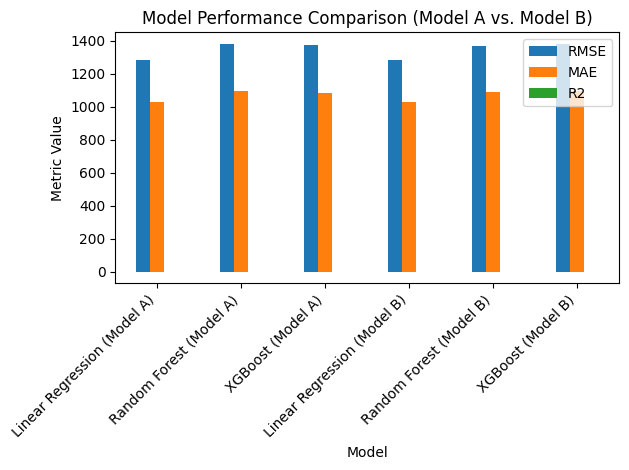

In [ ]:
# Generate a bar plot to visually compare the performance metrics (RMSE, MAE, R2) of Model A and Model B across different regression algorithms.
plt.figure(figsize=(12, 6))
combined_results_df.set_index('Model').plot(kind='bar')
plt.title("Model Performance Comparison (Model A vs. Model B)")
plt.ylabel("Metric Value")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 8. Feature Importance Analysis

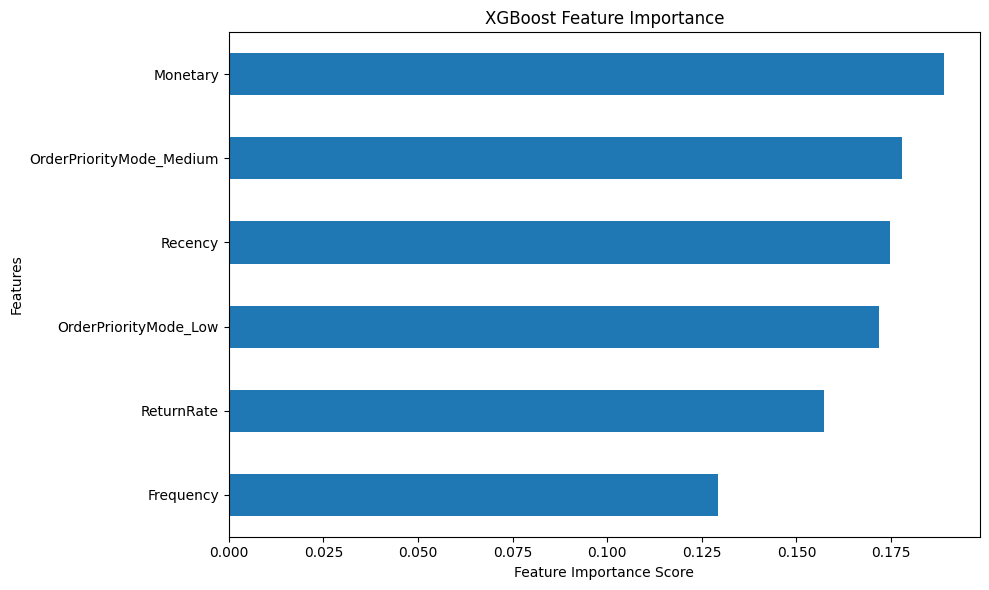

In [ ]:
# Train an XGBoost Regressor on the Model B training data and visualize the feature importance scores.
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train_B, y_train)

importance_xgb = pd.Series(xgb.feature_importances_, index=X_train_B.columns)
plt.figure(figsize=(10, 6))
importance_xgb.sort_values().plot(kind='barh')
plt.title("XGBoost Feature Importance")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

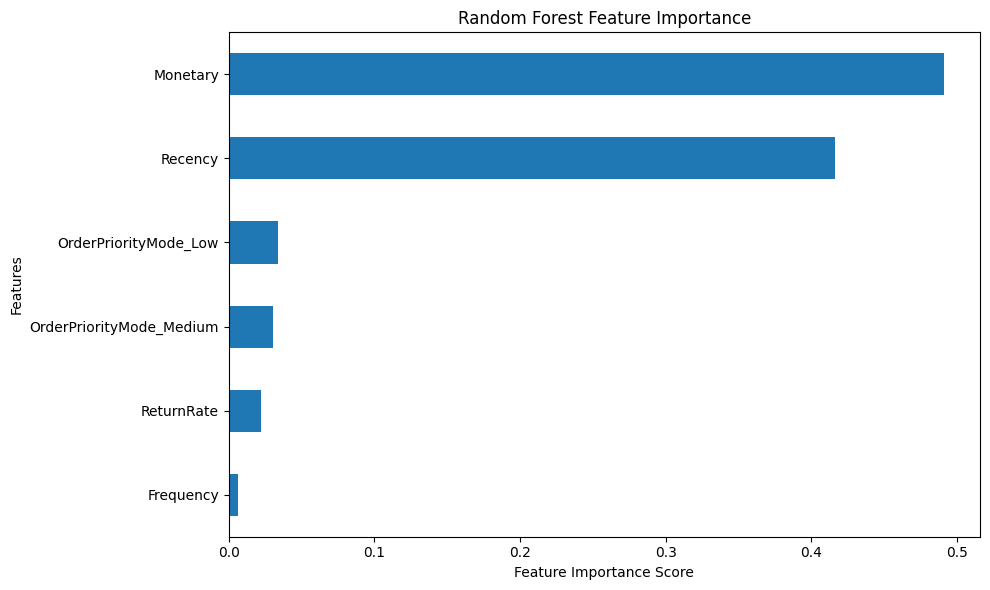

In [ ]:
# Train a Random Forest Regressor on the Model B training data and visualize the feature importance scores.
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_B, y_train)

importance = pd.Series(rf.feature_importances_, index=X_train_B.columns)
plt.figure(figsize=(10, 6))
importance.sort_values().plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

### SHAP Analysis for Model Interpretability

If a tuned Random Forest model exists, generate and plot SHAP (SHapley Additive exPlanations) values to interpret its predictions. Otherwise, print a message indicating the model is not found.


Generating SHAP values for Tuned Random Forest...


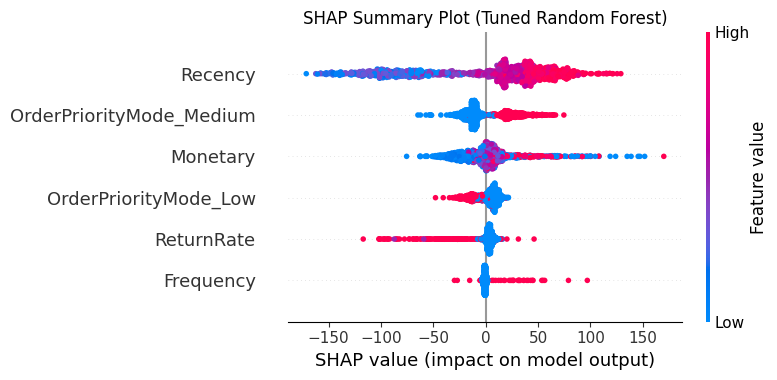

In [ ]:
# SHAP for Random Forest
if 'best_rf_model' in globals():
    print("Generating SHAP values for Tuned Random Forest...")
    # TreeExplainer works for both RF and XGBoost
    explainer_rf = shap.TreeExplainer(best_rf_model)
    shap_values_rf = explainer_rf.shap_values(X_test_B)

    # Plot Summary
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_rf, X_test_B, show=False)
    plt.title('SHAP Summary Plot (Tuned Random Forest)')
    plt.tight_layout()
    plt.show()
else:
    print("best_rf_model not found. Please run the hyperparameter tuning cell first.")

Generate SHAP values for the best XGBoost model (or a default if not tuned) to explain its predictions and visualize feature importance with SHAP summary plots.


Using best_xgb_model for SHAP analysis.


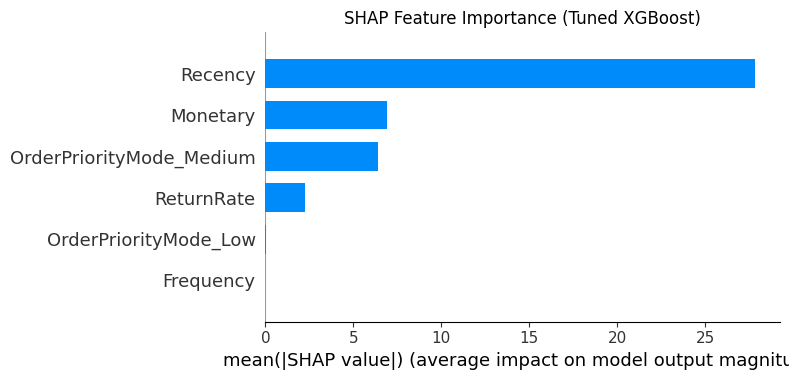

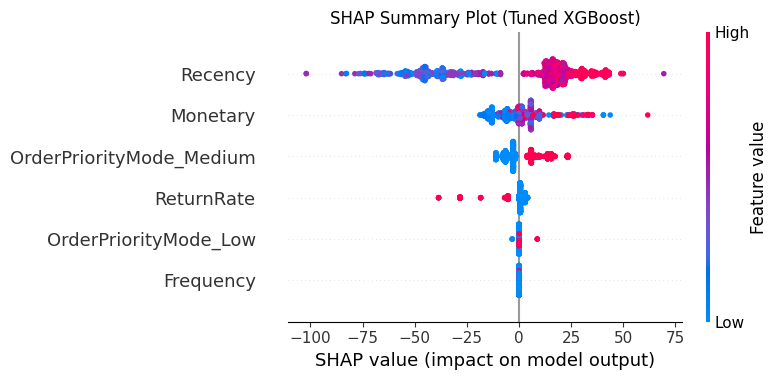

In [ ]:
# SHAP for XGBoost
if 'best_xgb_model' in globals() and best_xgb_model is not None:
    print("Using best_xgb_model for SHAP analysis.")
else:
    # Fallback if best_xgb_model is not defined (e.g., if tuning cell was skipped)
    print("best_xgb_model not found. Re-fitting a default XGBoost model for SHAP analysis.")
    best_xgb_model = XGBRegressor(random_state=42)
    best_xgb_model.fit(X_train_B, y_train)

# Create a SHAP explainer object
explainer = shap.TreeExplainer(best_xgb_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_B)

# Plot the summary of SHAP values
shap.summary_plot(shap_values, X_test_B, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Tuned XGBoost)')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_test_B, show=False)
plt.title('SHAP Summary Plot (Tuned XGBoost)')
plt.tight_layout()
plt.show()

### Feature Selection using Mutual Information

,MI Scores
Recency,0.007797
OrderPriorityMode_Medium,0.003782
ReturnRate,0.002777
Frequency,0.000000
Monetary,0.000000
OrderPriorityMode_Low,0.000000


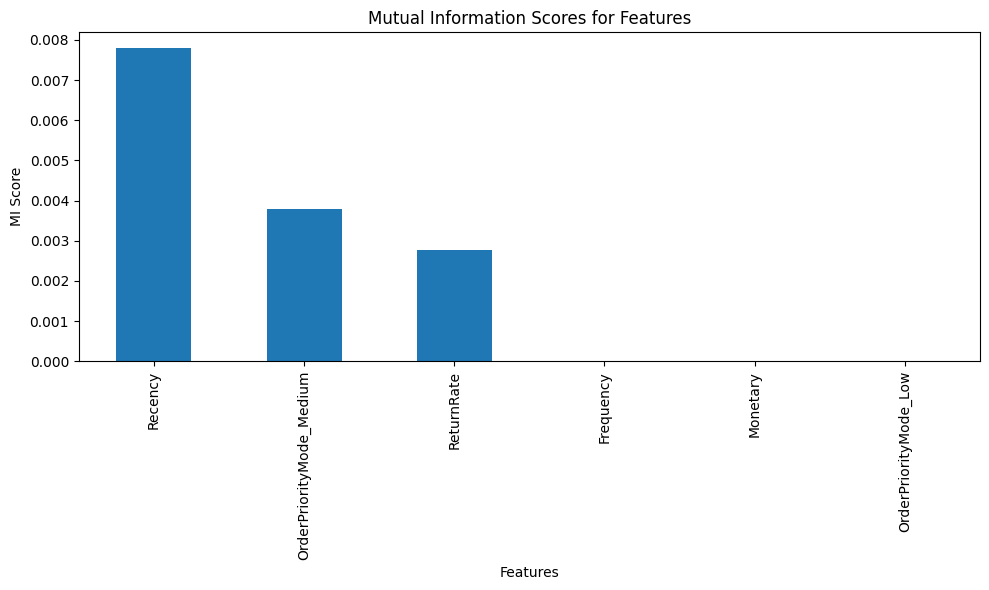

In [ ]:
# Calculate mutual information scores between each feature in X_B and the target variable y, then display and visualize these scores to identify most informative features.
mi_scores = mutual_info_regression(X_B, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X_B.columns)
mi_scores = mi_scores.sort_values(ascending=False)

display(mi_scores)

plt.figure(figsize=(10, 6))
mi_scores.plot(kind='bar')
plt.title("Mutual Information Scores for Features")
plt.ylabel("MI Score")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

### 9. Feature Selection using Recursive Feature Elimination (RFE) and Re-evaluation

Apply Recursive Feature Elimination (RFE) with a Linear Regression estimator to select the top N features (here, 5) from Model B's feature set. Re-evaluate models using these selected features and display updated performance metrics.


"Features selected by RFE: ['Recency', 'Frequency', 'Monetary', 'ReturnRate', 'OrderPriorityMode_Medium']"

,Model,RMSE,MAE,R2
0,Linear Regression (Model B - RFE),1281.121290,1028.611645,0.001206
1,Random Forest (Model B - RFE),1377.838908,1091.043474,-0.155622
2,XGBoost (Model B - RFE),1381.603656,1091.271262,-0.162053


,RMSE,MAE,R2
Model,,,
Linear Regression (Model A),1280.671629,1028.273259,0.001914
Random Forest (Model A),1381.298022,1092.285537,-0.161441
XGBoost (Model A),1374.347060,1085.557184,-0.149648
Linear Regression (Model B),1281.236106,1028.712563,0.001029
Random Forest (Model B),1368.210991,1086.595740,-0.139487
XGBoost (Model B),1380.576459,1092.315640,-0.160143
Linear Regression (Model B - RFE),1281.121290,1028.611645,0.001206
Random Forest (Model B - RFE),1377.838908,1091.043474,-0.155622
XGBoost (Model B - RFE),1381.603656,1091.271262,-0.162053


<Figure size 1500x700 with 0 Axes>

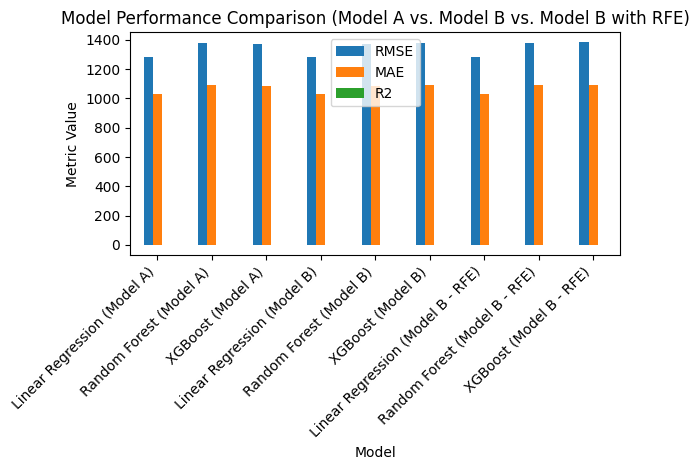

In [ ]:
# Using Linear Regression as the estimator for RFE
lr = LinearRegression()
rfe = RFE(estimator=lr, n_features_to_select=5, step=1) # You can adjust n_features_to_select
rfe.fit(X_B, y)

rfe_features = X_B.columns[rfe.support_]
display(f"Features selected by RFE: {list(rfe_features)}")

# Create a new X_B with selected features from RFE
X_B_rfe = X_B[rfe_features]

# Split data again with RFE selected features - This split is not used for cross_val_score, but might be useful for other steps
X_train_B_rfe, X_test_B_rfe, y_train_rfe, y_test_rfe = train_test_split(X_B_rfe, y, test_size=0.2, random_state=42)

# Evaluate models with RFE selected features using K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results_rfe = []
rmse_scores_B_rfe_dict = {}

for name, model in models.items():
    rmse_scores = np.sqrt(-cross_val_score(model, X_B_rfe, y, cv=kf, scoring='neg_mean_squared_error'))
    mae_scores = -cross_val_score(model, X_B_rfe, y, cv=kf, scoring='neg_mean_absolute_error')
    r2_scores = cross_val_score(model, X_B_rfe, y, cv=kf, scoring='r2')

    rmse_mean = np.mean(rmse_scores)
    mae_mean = np.mean(mae_scores)
    r2_mean = np.mean(r2_scores)

    results_rfe.append([f"{name} (Model B - RFE)", rmse_mean, mae_mean, r2_mean])
    rmse_scores_B_rfe_dict[name] = rmse_scores

results_df_rfe = pd.DataFrame(results_rfe, columns=['Model', 'RMSE', 'MAE', 'R2'])
display(results_df_rfe)

# Combine and display all results for comparison
combined_results_all = pd.concat([combined_results_df, results_df_rfe])
display(combined_results_all.set_index('Model'))

plt.figure(figsize=(15, 7))
combined_results_all.set_index('Model').plot(kind='bar')
plt.title("Model Performance Comparison (Model A vs. Model B vs. Model B with RFE)")
plt.ylabel("Metric Value")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 10. Statistical Significance Testing

In [ ]:
# Conduct paired t-tests to statistically compare the RMSE scores of models trained on Model A versus Model B feature sets, indicating significance if p < 0.05.
print("Paired T-test Results (Model A vs Model B on RMSE scores):\n")
for model_name in models.keys():
    if model_name in rmse_scores_A_dict and model_name in rmse_scores_B_dict:
        # Perform paired t-test
        t_statistic, p_value = stats.ttest_rel(rmse_scores_A_dict[model_name], rmse_scores_B_dict[model_name])
        print(f"--- {model_name} ---")
        print(f"  T-statistic: {t_statistic:.4f}")
        print(f"  P-value: {p_value:.4f}")
        if p_value < 0.05:
            print("  The difference in RMSE is statistically significant (p < 0.05)")
        else:
            print("  The difference in RMSE is NOT statistically significant (p >= 0.05)")
    else:
        print(f"  RMSE scores not found for {model_name} in both Model A and Model B for comparison.")

Paired T-test Results (Model A vs Model B on RMSE scores):

--- Linear Regression ---
  T-statistic: -1.3341
  P-value: 0.2531
  The difference in RMSE is NOT statistically significant (p >= 0.05)
--- Random Forest ---
  T-statistic: 5.8155
  P-value: 0.0044
  The difference in RMSE is statistically significant (p < 0.05)
--- XGBoost ---
  T-statistic: -2.7916
  P-value: 0.0492
  The difference in RMSE is statistically significant (p < 0.05)


### 11. Hyperparameter Tuning for Ensemble Models (Random Forest and XGBoost)

Perform hyperparameter tuning using GridSearchCV for Random Forest and XGBoost regressors on Model B's training data. Print the best parameters and corresponding RMSE for each.


In [ ]:
# Random Forest Regressor Hyperparameter Tuning
print("Tuning Random Forest Regressor...")
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [5, 10, None]
}
grid_search_rf = GridSearchCV(estimator=RandomForestRegressor(random_state=42), param_grid=param_grid_rf,
                              cv=kf, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train_B, y_train)

best_rf_model = grid_search_rf.best_estimator_
print(f"Best Random Forest parameters: {grid_search_rf.best_params_}")
print(f"Best Random Forest RMSE: {np.sqrt(-grid_search_rf.best_score_)}")

# XGBoost Regressor Hyperparameter Tuning
print("\nTuning XGBoost Regressor...")
param_grid_xgb = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}
grid_search_xgb = GridSearchCV(estimator=XGBRegressor(random_state=42, eval_metric='rmse'), param_grid=param_grid_xgb,
                               cv=kf, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_search_xgb.fit(X_train_B, y_train)

best_xgb_model = grid_search_xgb.best_estimator_
print(f"Best XGBoost parameters: {grid_search_xgb.best_params_}")
print(f"Best XGBoost RMSE: {np.sqrt(-grid_search_xgb.best_score_)}")

Tuning Random Forest Regressor...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Random Forest parameters: {'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 100}
Best Random Forest RMSE: 1285.7936994540948

Tuning XGBoost Regressor...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best XGBoost parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
Best XGBoost RMSE: 1285.2694122915834


### 12. Re-evaluate Models with Tuned Hyperparameters

,Model,RMSE,MAE,R2
0,Tuned Random Forest,1283.068839,1030.670036,-0.001840
1,Tuned XGBoost,1281.906658,1029.176728,-0.000021


,RMSE,MAE,R2
Model,,,
Linear Regression (Model A),1280.671629,1028.273259,0.001914
Random Forest (Model A),1381.298022,1092.285537,-0.161441
XGBoost (Model A),1374.347060,1085.557184,-0.149648
Linear Regression (Model B),1281.236106,1028.712563,0.001029
Random Forest (Model B),1368.210991,1086.595740,-0.139487
XGBoost (Model B),1380.576459,1092.315640,-0.160143
Linear Regression (Model B - RFE),1281.121290,1028.611645,0.001206
Random Forest (Model B - RFE),1377.838908,1091.043474,-0.155622
XGBoost (Model B - RFE),1381.603656,1091.271262,-0.162053


<Figure size 1500x700 with 0 Axes>

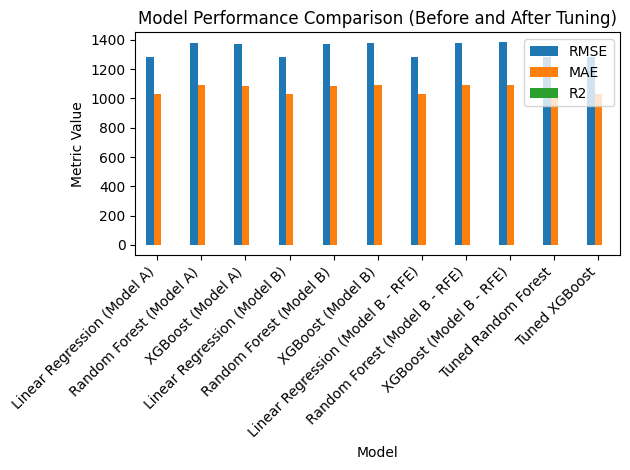

In [ ]:
# Re-evaluate the tuned Random Forest and XGBoost models using K-Fold cross-validation on the full Model B feature set. Display their performance metrics and compare them against previous untuned results using a combined bar plot.
tuned_models = {
    "Tuned Random Forest": best_rf_model,
    "Tuned XGBoost": best_xgb_model
}

results_tuned = []

for name, model in tuned_models.items():
    rmse_scores = np.sqrt(-cross_val_score(model, X_B, y, cv=kf, scoring='neg_mean_squared_error'))
    mae_scores = -cross_val_score(model, X_B, y, cv=kf, scoring='neg_mean_absolute_error')
    r2_scores = cross_val_score(model, X_B, y, cv=kf, scoring='r2')

    rmse_mean = np.mean(rmse_scores)
    mae_mean = np.mean(mae_scores)
    r2_mean = np.mean(r2_scores)

    results_tuned.append([name, rmse_mean, mae_mean, r2_mean])

results_df_tuned = pd.DataFrame(results_tuned, columns=['Model', 'RMSE', 'MAE', 'R2'])
display(results_df_tuned)

# Combine with previous results for full comparison
combined_results_all_tuned = pd.concat([combined_results_all, results_df_tuned])
display(combined_results_all_tuned.set_index('Model'))

plt.figure(figsize=(15, 7))
combined_results_all_tuned.set_index('Model').plot(kind='bar')
plt.title("Model Performance Comparison (Before and After Tuning)")
plt.ylabel("Metric Value")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()